# House Prices 

Objectif: prédire SalePrice

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_log_error

In [63]:
## 0) Chargement des données
train_df = pd.read_csv('Data/Train.csv')

# Variables explicatives et cible
X = train_df.drop(['SalePrice', 'Id'], axis=1)
y = train_df['SalePrice']

# Types de colonnes
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'string']).columns

print(f"Train shape: {train_df.shape}")
print(f"Variables numeriques: {len(numeric_features)} | categorielle: {len(categorical_features)}")

Train shape: (1460, 81)
Variables numeriques: 36 | categorielle: 43


## 1) Data mining et EDA

Dans cette section:
1. Qualite des donnees (types, cardinalité, valeurs manquantes)
2. Visualisation de la cible
3. Correlations numeriques principales

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 200)

if 'train_df' not in globals():
    train_df = pd.read_csv('Data/Train.csv')

print(f"Lignes: {train_df.shape[0]} | Colonnes: {train_df.shape[1]}")
train_df.head(3)

Lignes: 1460 | Colonnes: 81


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


### Checklist EDA avant modelisation

- Variables avec beaucoup de NA identifiées
- Forme de la cible verifiée (brute vs log)
- Variables numériques les plus correlées repérées

Quand cette checklist est validee, on passe au preprocessing puis aux modeles.

In [65]:
missing_pct = (train_df.isna().mean() * 100).sort_values(ascending=False)

profil = pd.DataFrame({
    'dtype': train_df.dtypes.astype(str),
    'n_unique': train_df.nunique(),
    'missing_%': (train_df.isna().mean() * 100).round(2)
}).sort_values('missing_%', ascending=False)

print('Top variables avec valeurs manquantes:')
display(profil.head(15))

Top variables avec valeurs manquantes:


,dtype,n_unique,missing_%
PoolQC,str,3,99.52
MiscFeature,str,4,96.30
Alley,str,2,93.77
Fence,str,4,80.75
MasVnrType,str,3,59.73
FireplaceQu,str,5,47.26
LotFrontage,float64,110,17.74
GarageQual,str,5,5.55
GarageFinish,str,3,5.55
GarageType,str,6,5.55


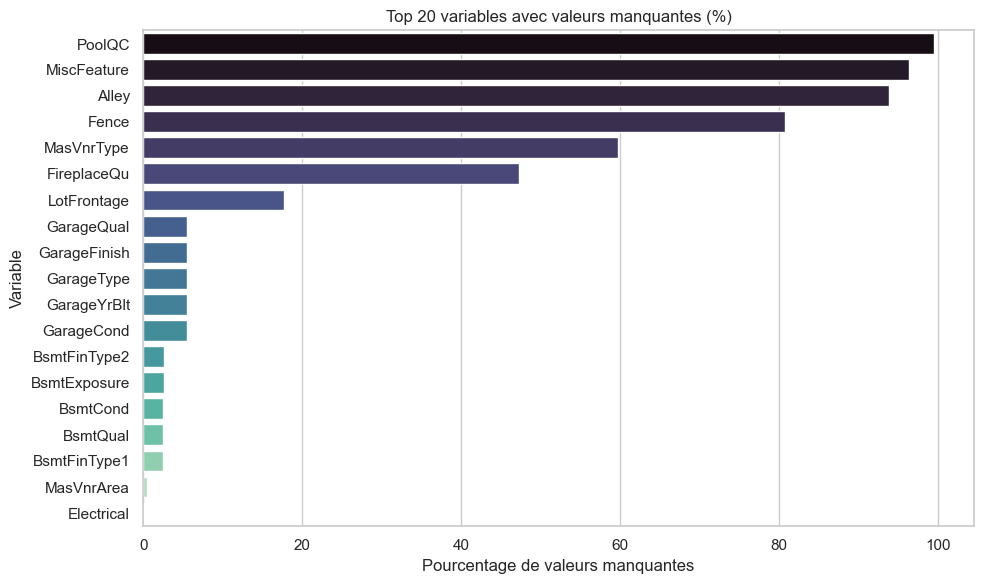

In [66]:
top_missing = missing_pct[missing_pct > 0].head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_missing.values, y=top_missing.index, hue=top_missing.index, legend=False, palette='mako')
plt.title('Top 20 variables avec valeurs manquantes (%)')
plt.xlabel('Pourcentage de valeurs manquantes')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

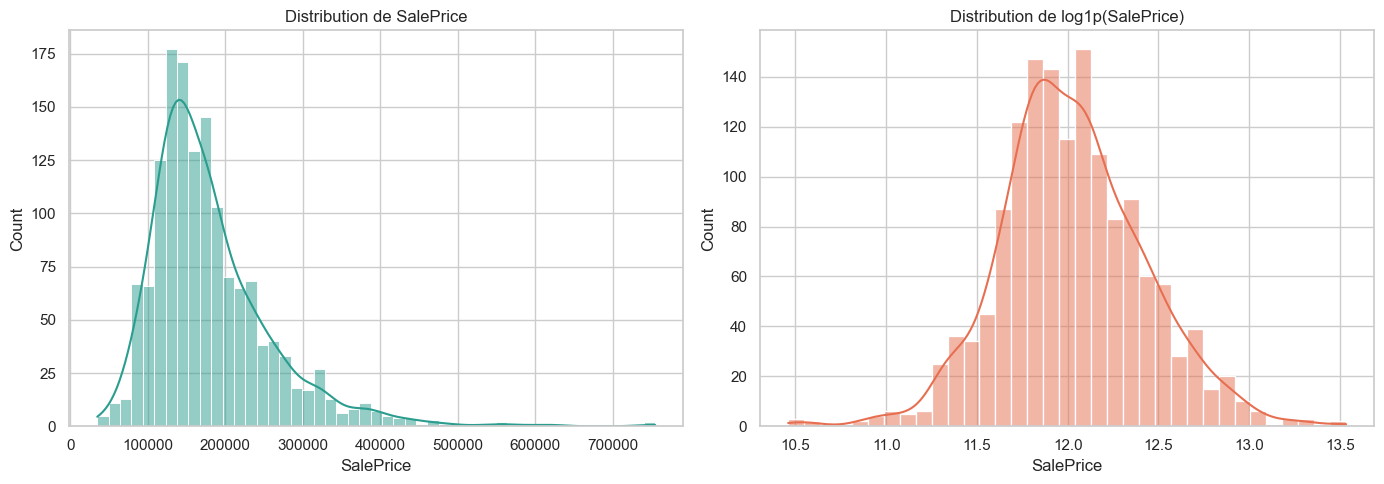

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train_df['SalePrice'], kde=True, ax=axes[0], color='#2a9d8f')
axes[0].set_title('Distribution de SalePrice')

sns.histplot(np.log1p(train_df['SalePrice']), kde=True, ax=axes[1], color='#e76f51')
axes[1].set_title('Distribution de log1p(SalePrice)')

plt.tight_layout()
plt.show()

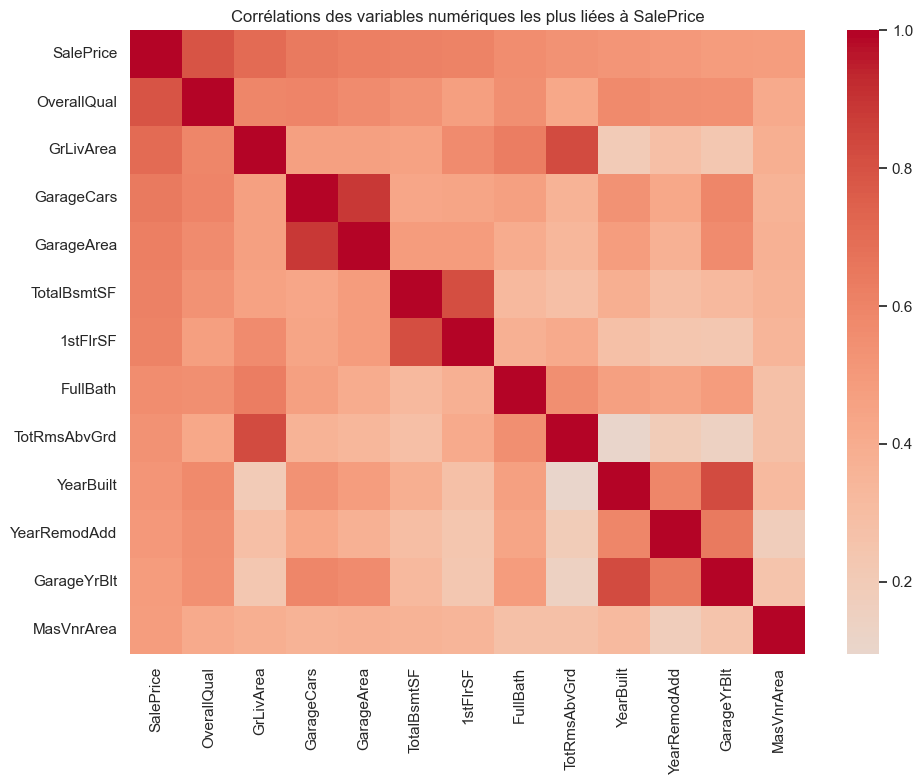

In [68]:
num_df = train_df.select_dtypes(include=['int64', 'float64'])

corr_with_target = num_df.corr(numeric_only=True)['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False)
top_num_cols = corr_with_target.head(12).index.tolist()
plot_cols = ['SalePrice'] + top_num_cols

plt.figure(figsize=(10, 8))
sns.heatmap(num_df[plot_cols].corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Corrélations des variables numériques les plus liées à SalePrice')
plt.tight_layout()
plt.show()

## 2) Modèle final 

Après l'EDA, on entraîne directement le modèle final basé sur les 5 catégories recommandées.

In [69]:
# Modèle final: 4 variables numériques + Neighborhood
# Correspondance prof: qualité, taille, cave, âge/rénovation, emplacement
top_4_numeric_alt = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'YearRemodAdd']
cat_features_alt = ['Neighborhood']

numeric_transformer_alt = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer_alt = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_alt = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_alt, top_4_numeric_alt),
        ('cat', categorical_transformer_alt, cat_features_alt)
    ]
)

rf_model_alt = Pipeline(steps=[
    ('preprocessor', preprocessor_alt),
    ('regressor', RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    ))
])

X_alt = train_df[top_4_numeric_alt + cat_features_alt].copy()
rf_model_alt.fit(X_alt, y)

print("Modèle final entraîné.")
print(f"Variables numériques: {top_4_numeric_alt}")
print(f"Variable catégorielle: {cat_features_alt}")

Modèle final entraîné.
Variables numériques: ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'YearRemodAdd']
Variable catégorielle: ['Neighborhood']


## 3) Évaluation du modèle (RMSE + RMSLE)

Vérification de la pertinence des scores en validation croisée, avec la métrique Kaggle (RMSLE).

In [70]:
# Évaluation en validation croisée
rmse_scores_alt = -cross_val_score(
    rf_model_alt,
    X_alt,
    y,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

# RMSLE out-of-fold (aligné avec la logique Kaggle)
y_true_cv = []
predictions_cv = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)
for train_idx, val_idx in kf.split(X_alt):
    X_train_cv, X_val_cv = X_alt.iloc[train_idx], X_alt.iloc[val_idx]
    y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

    rf_temp = Pipeline(steps=[
        ('preprocessor', preprocessor_alt),
        ('regressor', RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1))
    ])
    rf_temp.fit(X_train_cv, y_train_cv)

    pred_val = rf_temp.predict(X_val_cv)
    pred_val = np.clip(pred_val, a_min=0, a_max=None)

    predictions_cv.append(pred_val)
    y_true_cv.append(y_val_cv.values)

y_true_cv = np.concatenate(y_true_cv)
predictions_cv = np.concatenate(predictions_cv)
rmsle_final = np.sqrt(mean_squared_log_error(y_true_cv, predictions_cv))

print("\n" + "="*80)
print("SCORES DE VALIDATION CROISÉE")
print("="*80)
print(f"RMSE moyen (USD): {rmse_scores_alt.mean():.2f}")
print(f"Écart-type RMSE: {rmse_scores_alt.std():.2f}")
print(f"RMSLE (métrique Kaggle): {rmsle_final:.6f}")
print(f"CV% (stabilité): {(rmse_scores_alt.std()/rmse_scores_alt.mean()*100):.2f}%")


SCORES DE VALIDATION CROISÉE
RMSE moyen (USD): 30827.02
Écart-type RMSE: 3084.29
RMSLE (métrique Kaggle): 0.169573
CV% (stabilité): 10.01%


In [71]:
## 4) Soumission Kaggle (modèle final)

# Chargement du jeu de test
test_df = pd.read_csv('Data/Test.csv')
X_test_alt = test_df[top_4_numeric_alt + cat_features_alt].copy()

# Prédictions avec le modèle final
predictions_prof_aligned = rf_model_alt.predict(X_test_alt)
predictions_prof_aligned = np.clip(predictions_prof_aligned, a_min=0, a_max=None)

# Fichier de soumission
submission_prof_aligned = pd.DataFrame({
    'Id': test_df['Id'],
    'SalePrice': predictions_prof_aligned
})
submission_prof_aligned.to_csv('julien_submission.csv', index=False)

print("\n" + "="*80)
print("SOUMISSION FINALE GÉNÉRÉE")
print("="*80)
print("Modèle: 5 variables prof-aligned")
print("Variables:")
print(f"  - Numériques: {', '.join(top_4_numeric_alt)}")
print(f"  - Catégorielles: {', '.join(cat_features_alt)}")
print(f"Fichier: julien_submission.csv")
print(f"RMSLE de référence (CV): {rmsle_final:.6f}")


SOUMISSION FINALE GÉNÉRÉE
Modèle: 5 variables prof-aligned
Variables:
  - Numériques: OverallQual, GrLivArea, TotalBsmtSF, YearRemodAdd
  - Catégorielles: Neighborhood
Fichier: julien_submission.csv
RMSLE de référence (CV): 0.169573


## Résumé final

**Ordre logique d'exécution:**
1. Section 0: Imports et chargement des données
2. Section 1: EDA (qualité des données, distributions, corrélations)
3. Section 2: Modèle final prof-aligned
4. Section 3: Évaluation croisée (RMSE + RMSLE)
5. Section 4: Génération de la soumission Kaggle

**Modèle conservé (utile):**
- OverallQual, GrLivArea, TotalBsmtSF, YearRemodAdd, Neighborhood
- Couverture des 5 catégories du professeur

**Fichier de soumission:**
- julien_submission.csv